# Objective

The main objective of this analysis is to figure out what drives employment and what causes someone to be offered a job.

# Code

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/cleaned/employment_cleaned.csv')

In [3]:
skills = pd.read_csv('../data/cleaned/skills.csv')

## General

In [4]:
df.head(5)

,id,AgeAbove35,Accessibility,EdLevel,Employment,Gender,MentalHealth,MainBranch,YearsCode,YearsCodePro,Country,PreviousSalary,HaveWorkedWith,ComputerSkills,Employed
0,0,0,False,Master,1,Man,False,Dev,7,4,Sweden,51552.0,"['C++', 'Python', 'Git', 'PostgreSQL']",4,0
1,1,0,False,Undergraduate,1,Man,False,Dev,12,5,Spain,46482.0,"['Bash/Shell', 'HTML/CSS', 'JavaScript', 'Node...",12,1
2,2,0,False,Master,1,Man,False,Dev,15,6,Germany,77290.0,"['C', 'C++', 'Java', 'Perl', 'Ruby', 'Git', 'R...",7,0
3,3,0,False,Undergraduate,1,Man,False,Dev,9,6,Canada,46135.0,"['Bash/Shell', 'HTML/CSS', 'JavaScript', 'PHP'...",13,0
4,4,1,False,PhD,0,Man,False,NotDev,40,30,Singapore,160932.0,"['C++', 'Python']",2,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73462 entries, 0 to 73461
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              73462 non-null  int64  
 1   AgeAbove35      73462 non-null  int64  
 2   Accessibility   73462 non-null  bool   
 3   EdLevel         73462 non-null  str    
 4   Employment      73462 non-null  int64  
 5   Gender          73462 non-null  str    
 6   MentalHealth    73462 non-null  bool   
 7   MainBranch      73462 non-null  str    
 8   YearsCode       73462 non-null  int64  
 9   YearsCodePro    73462 non-null  int64  
 10  Country         73462 non-null  str    
 11  PreviousSalary  73462 non-null  float64
 12  HaveWorkedWith  73399 non-null  str    
 13  ComputerSkills  73462 non-null  int64  
 14  Employed        73462 non-null  int64  
dtypes: bool(2), float64(1), int64(7), str(5)
memory usage: 7.4 MB


In [6]:
df.describe()

,id,AgeAbove35,Employment,YearsCode,YearsCodePro,PreviousSalary,ComputerSkills,Employed
count,73462.000000,73462.000000,73462.000000,73462.000000,73462.000000,73462.000000,73462.000000,73462.000000
mean,36730.500000,0.349065,0.883096,14.218902,9.098377,67750.260611,13.428221,0.536223
std,21206.797075,0.476678,0.321308,9.405172,7.960201,49488.142118,7.057835,0.498690
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,18365.250000,0.000000,1.000000,7.000000,3.000000,28839.000000,8.000000,0.000000
50%,36730.500000,0.000000,1.000000,12.000000,7.000000,57588.000000,13.000000,1.000000
75%,55095.750000,1.000000,1.000000,20.000000,12.000000,95979.000000,17.000000,1.000000
max,73461.000000,1.000000,1.000000,50.000000,50.000000,224000.000000,107.000000,1.000000


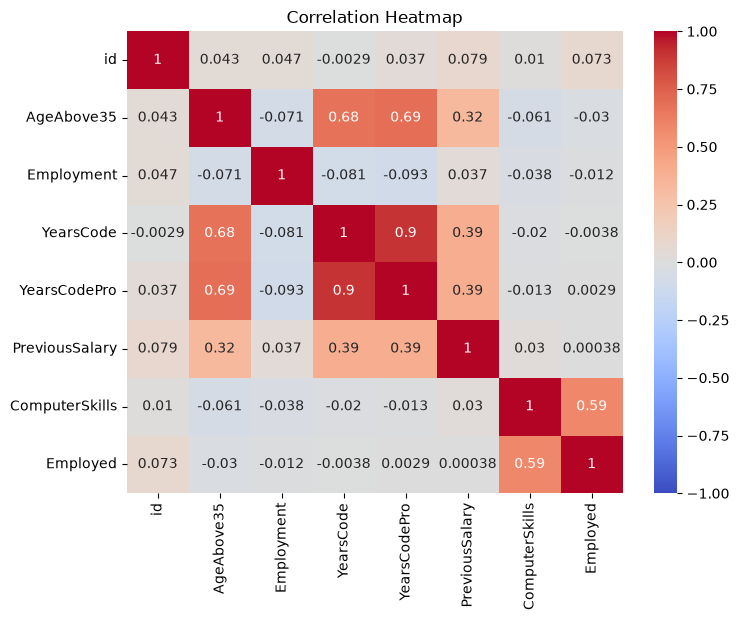

In [7]:
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=["number"])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)

plt.title("Correlation Heatmap")
plt.show()

## PreviousSalary, Employment, and Employed

In [8]:
df[['PreviousSalary', 'Employment', 'Employed']].describe()

,PreviousSalary,Employment,Employed
count,73462.000000,73462.000000,73462.000000
mean,67750.260611,0.883096,0.536223
std,49488.142118,0.321308,0.498690
min,1.000000,0.000000,0.000000
25%,28839.000000,1.000000,0.000000
50%,57588.000000,1.000000,1.000000
75%,95979.000000,1.000000,1.000000
max,224000.000000,1.000000,1.000000


Average previous salary is 67750.26

~88.3% of persons were already working at the time of the study.

~53.6% of persons got a job offer after the study.

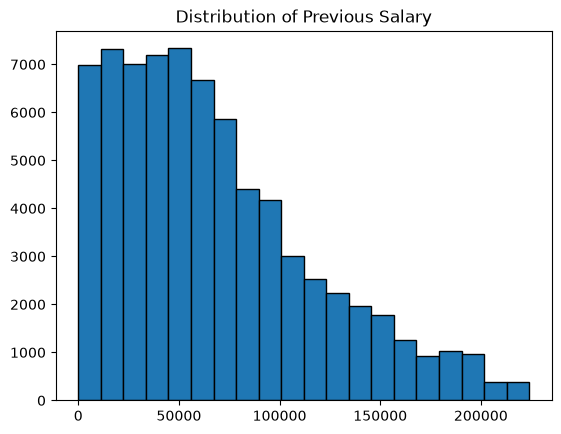

In [9]:
plt.hist(df['PreviousSalary'], bins=20, edgecolor='black')
plt.title("Distribution of Previous Salary")
plt.show()

The distribution of previous salary is right-skewed. Indicating that few persons have relatively high salaries and most persons have relatively low salaries.

In [10]:
df[df['Employment']==1]['Employed'].mean()

np.float64(0.5340197922125968)

In [11]:
df[df['Employed']==1]['Employment'].mean()

np.float64(0.87946791226645)

~53.4% of persons who were already employed before the study received a job offer after the study.

~87.9% of persons who got a job offer after the study were already employed.

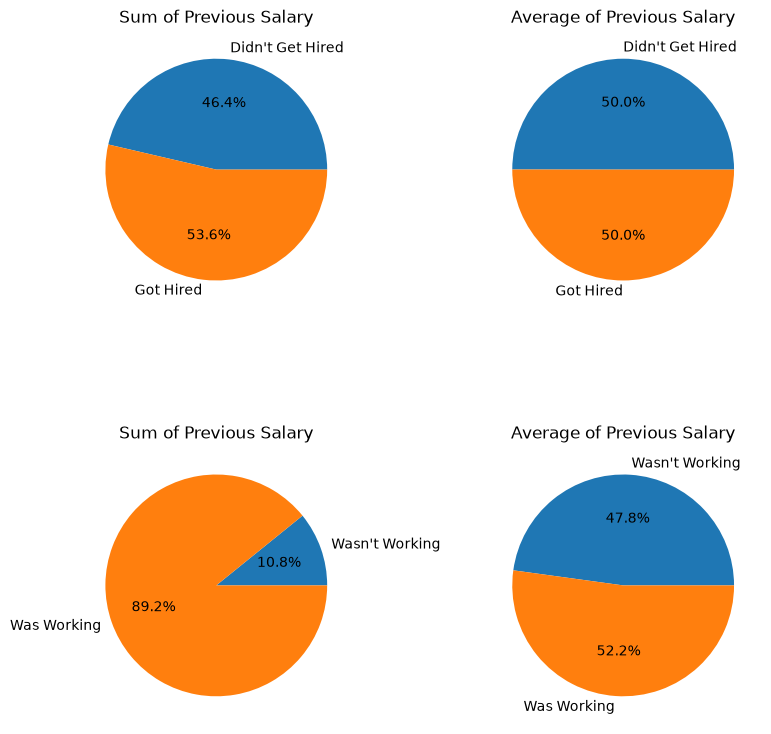

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(9, 9))
plt.subplots_adjust(hspace=0.5, wspace=0.4)

ax1 = axes[0][0]
ax1.set_title("Sum of Previous Salary")
ax1.pie(df.groupby('Employed')['PreviousSalary'].sum(), labels=["Didn't Get Hired", "Got Hired"], autopct='%1.1f%%')

ax2 = axes[0][1]
ax2.set_title("Average of Previous Salary")
ax2.pie(df.groupby('Employed')['PreviousSalary'].mean(), labels=["Didn't Get Hired", "Got Hired"], autopct='%1.1f%%')

ax3 = axes[1][0]
ax3.set_title("Sum of Previous Salary")
ax3.pie(df.groupby('Employment')['PreviousSalary'].sum(), labels=["Wasn't Working", "Was Working"], autopct='%1.1f%%')

ax4 = axes[1][1]
ax4.set_title("Average of Previous Salary")
ax4.pie(df.groupby('Employment')['PreviousSalary'].mean(), labels=["Wasn't Working", "Was Working"], autopct='%1.1f%%')

plt.show()

## Skills

In [13]:
skills['HaveWorkedWith'].nunique()

116

There are 116 unique skills.

In [14]:
df[['ComputerSkills', 'Employed']].corr()

,ComputerSkills,Employed
ComputerSkills,1.000000,0.585545
Employed,0.585545,1.000000


In [15]:
top_skills = skills.HaveWorkedWith.value_counts().head(10)

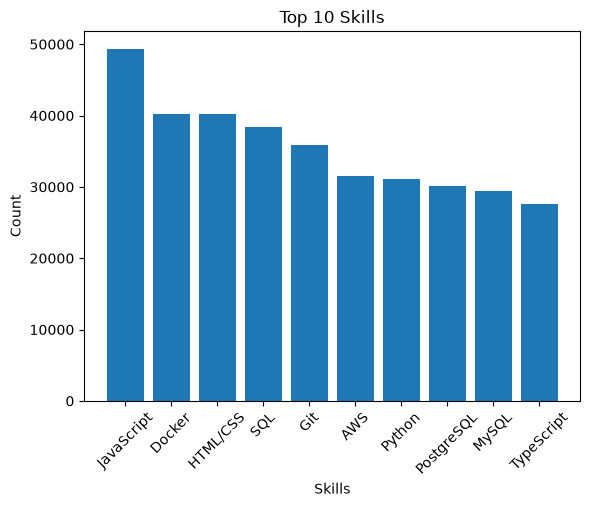

In [16]:
plt.bar(top_skills.index, top_skills.values)
plt.title('Top 10 Skills')  
plt.xlabel('Skills')
plt.ylabel('Count') 
plt.xticks(rotation=45)
plt.show()


In [17]:
skills_salary = skills.groupby('HaveWorkedWith').apply(lambda x: (x['id'].map(df.groupby('id')['PreviousSalary'].sum())).mean())
top_skills_salary = skills_salary.nlargest(10)

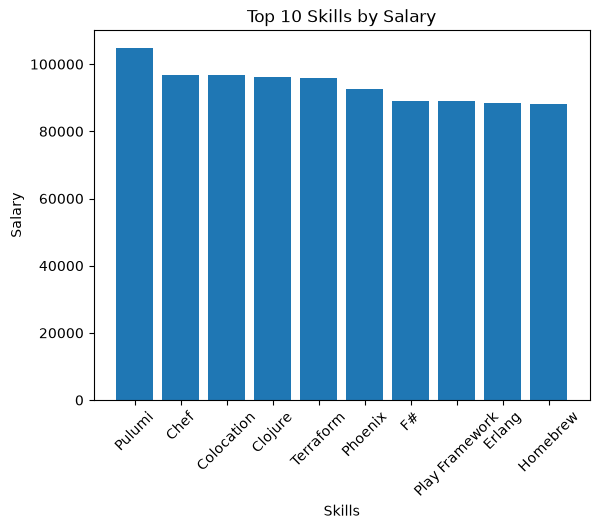

In [18]:
plt.bar(top_skills_salary.index, top_skills_salary.values)
plt.title('Top 10 Skills by Salary')  
plt.xlabel('Skills')
plt.ylabel('Salary') 
plt.xticks(rotation=45)
plt.show()

In [19]:
# Job-offered with no skills or Having skills but not offered a job

job_no_skills = df[(df.ComputerSkills == 0) & (df.Employed == 1)]
print(f"Number of job-offered individuals with no computer skills: {len(job_no_skills)}")
job_with_skills = df[(df.ComputerSkills == 1) & (df.Employed == 0)]
print(f"Number of individuals with computer skills but not offered a job: {len(job_with_skills)}")

Number of job-offered individuals with no computer skills: 0
Number of individuals with computer skills but not offered a job: 370


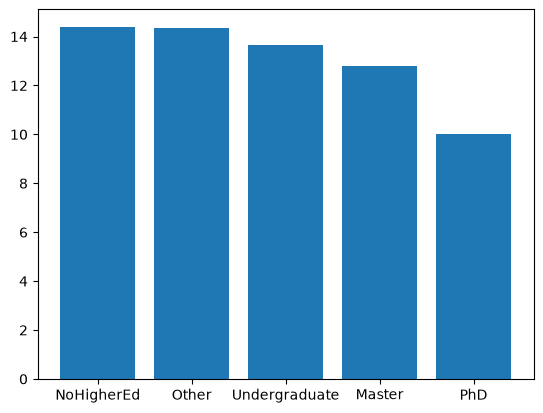

In [20]:
elevel_skills = df.groupby('EdLevel')['ComputerSkills'].mean().sort_values(ascending=False)    

plt.bar(elevel_skills.index, elevel_skills.values)
plt.show()

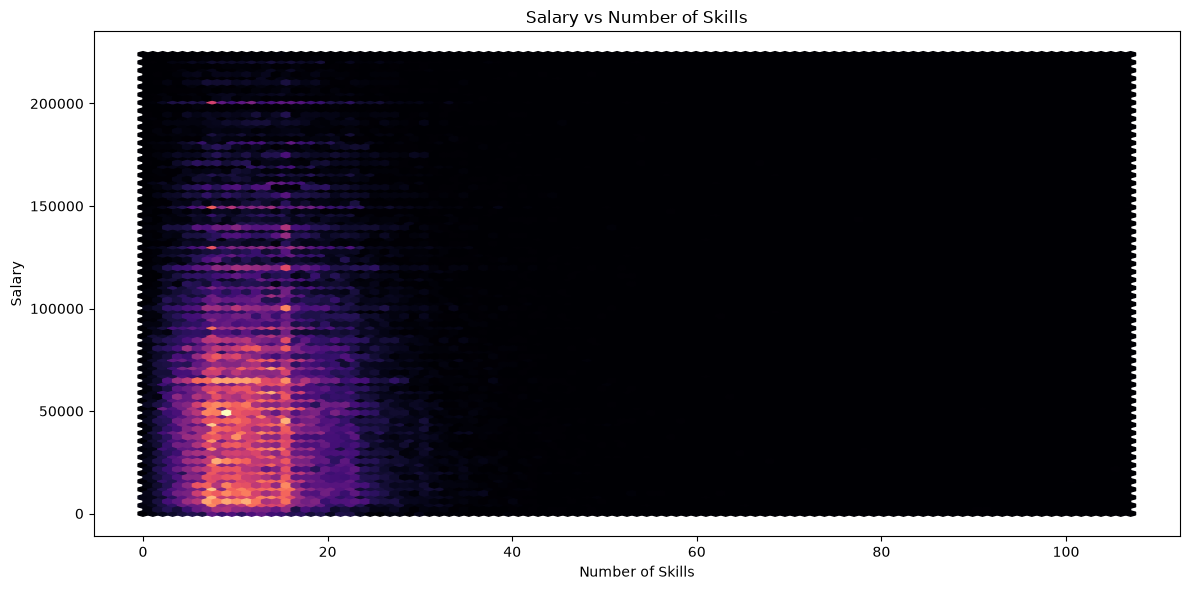

In [21]:
# skills vs salary 

plt.figure(figsize=(12,6))        
plt.hexbin(df['ComputerSkills'], df['PreviousSalary'], cmap='magma')
plt.title('Salary vs Number of Skills')
plt.xlabel('Number of Skills')
plt.ylabel('Salary')
plt.tight_layout()
plt.show()


Average skills - Under 35: 13.74
Average skills - 35+: 12.84


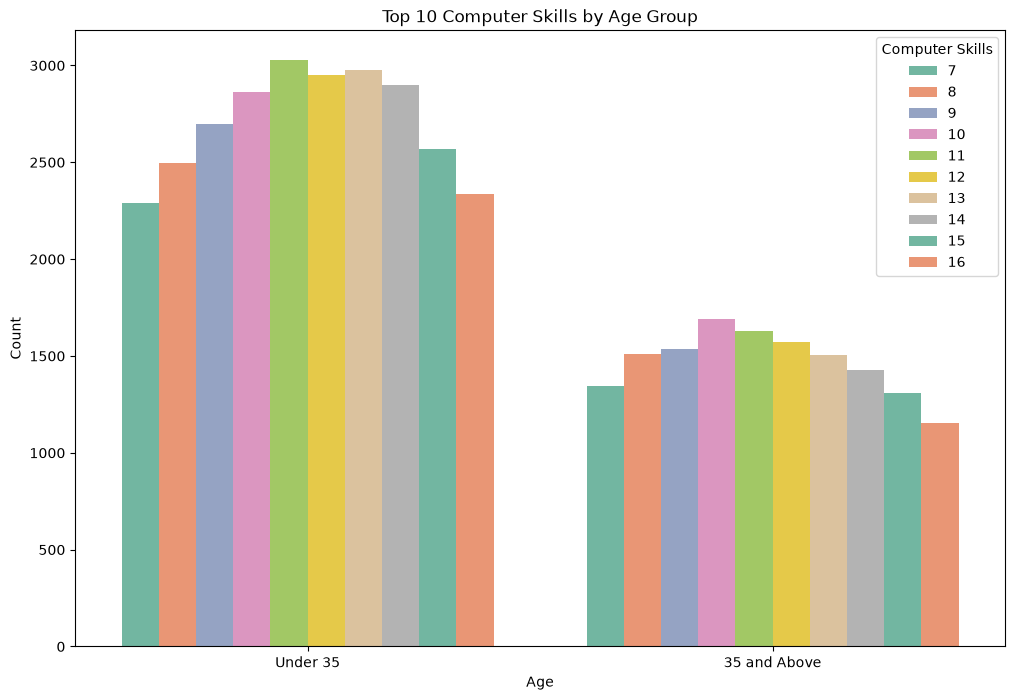

In [22]:
if 'AgeAbove35' in df.columns:
        young_skills = df[df['AgeAbove35'] == 0]['ComputerSkills']
        old_skills = df[df['AgeAbove35'] == 1]['ComputerSkills']
        
        print(f"Average skills - Under 35: {young_skills.mean():.2f}")
        print(f"Average skills - 35+: {old_skills.mean():.2f}")  

top_skills = df.ComputerSkills.value_counts().head(10).index.tolist()
df_top_skills = df[df['ComputerSkills'].isin(top_skills)]

plt.figure(figsize=(12, 8))
sns.countplot(x='AgeAbove35', hue='ComputerSkills', data=df_top_skills, palette='Set2')
plt.title('Top 10 Computer Skills by Age Group')
plt.xlabel('Age')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Under 35', '35 and Above'])
plt.legend(title='Computer Skills', loc='upper right')
plt.show()
       

## Years of Coding Experience

In [23]:
df['NonPro_Experience'] = df['YearsCode'] - df['YearsCodePro']

In [24]:
df['NonPro_Experience'].describe()

count    73462.000000
mean         5.120525
std          4.111047
min        -50.000000
25%          2.000000
50%          4.000000
75%          7.000000
max         43.000000
Name: NonPro_Experience, dtype: float64

In [25]:
df['NonPro_Experience'] = df['NonPro_Experience'].apply(lambda x: x if x >= 0 else None)

Approximately 0.8% of respondents reported more years of professional coding than total coding experience. Because this contradicts the survey definitions, the resulting negative non-professional experience values were treated as inconsistent and excluded from analyses

In [26]:
df['YearsCode_Bin'] = pd.cut(df['YearsCode'], bins=[-1, 5, 10, 15, 20, 30, 50], 
                             labels=['0-5 yrs', '6-10 yrs', '11-15 yrs', '16-20 yrs', '21-30 yrs', '31+ yrs'])
df['YearsCodePro_Bin'] = pd.cut(df['YearsCodePro'], bins=[-1, 2, 5, 10, 15, 20, 50], 
                                labels=['0-2 yrs', '3-5 yrs', '6-10 yrs', '11-15 yrs', '16-20 yrs', '21+ yrs'])
df['NonPro_Bin'] = pd.cut(df['NonPro_Experience'], bins=[-1, 2, 5, 10, 50], 
                          labels=['0-2 yrs', '3-5 yrs', '6-10 yrs', '11+ yrs'])
df['Skill_Tier'] = pd.qcut(df['ComputerSkills'], q=3, 
                           labels=['Low Skills (0-9)', 'Medium Skills (10-16)', 'High Skills (17+)'])

In [27]:
# Aggregate employment rate, skills, and salary across Total Experience bins
df.groupby('YearsCode_Bin', observed=False).agg(
    total_candidates=('Employed', 'count'),
    hired_candidates=('Employed', 'sum'),
    hiring_rate=('Employed', 'mean'),
    avg_pro_exp=('YearsCodePro', 'mean'),
    avg_skills=('ComputerSkills', 'mean'),
    avg_salary=('PreviousSalary', 'mean')
).reset_index()

,YearsCode_Bin,total_candidates,hired_candidates,hiring_rate,avg_pro_exp,avg_skills,avg_salary
0,0-5 yrs,10686,5341,0.499813,2.094235,12.560827,37661.976043
1,6-10 yrs,22951,12391,0.539889,4.303647,13.648817,54868.393621
2,11-15 yrs,15207,8357,0.549550,7.821003,13.852962,70198.093641
3,16-20 yrs,9619,5349,0.556087,11.719721,13.806633,81875.932425
4,21-30 yrs,9847,5465,0.554991,17.642226,13.615314,94036.938052
5,31+ yrs,5152,2489,0.483113,27.531832,11.926825,103703.519798


In [28]:
# Aggregate employment metrics across Professional Experience bins
df.groupby('YearsCodePro_Bin', observed=False).agg(
    total_candidates=('Employed', 'count'),
    hired_candidates=('Employed', 'sum'),
    hiring_rate=('Employed', 'mean'),
    avg_pro_exp=('YearsCodePro', 'mean'),
    avg_skills=('ComputerSkills', 'mean'),
    avg_salary=('PreviousSalary', 'mean')
).reset_index()

,YearsCodePro_Bin,total_candidates,hired_candidates,hiring_rate,avg_pro_exp,avg_skills,avg_salary
0,0-2 yrs,12691,6419,0.505792,1.249862,12.608699,37235.552754
1,3-5 yrs,18830,10019,0.532076,3.973022,13.499575,53354.114604
2,6-10 yrs,19492,10659,0.546840,7.891084,13.835471,72864.286374
3,11-15 yrs,9733,5512,0.566321,13.032159,14.076338,84493.763280
4,16-20 yrs,5494,3070,0.558791,18.169094,13.613396,92477.370404
5,21+ yrs,7222,3713,0.514124,27.310302,12.568818,103729.732207


In [29]:
df.groupby('NonPro_Bin', observed=False).agg(
    total_candidates=('Employed', 'count'),
    hiring_rate=('Employed', 'mean'),
    avg_total_exp=('YearsCode', 'mean'),
    avg_pro_exp=('YearsCodePro', 'mean')
).reset_index()

,NonPro_Bin,total_candidates,hiring_rate,avg_total_exp,avg_pro_exp
0,0-2 yrs,18342,0.522135,9.413695,8.198343
1,3-5 yrs,28743,0.553700,12.448527,8.434262
2,6-10 yrs,19187,0.531662,17.397092,9.799708
3,11+ yrs,6602,0.512118,26.625114,12.181612


In [30]:
# Cross-analyze how skill tiers alter employment rates within experience levels
df.groupby(['YearsCodePro_Bin', 'Skill_Tier'], observed=False).agg(
    candidate_count=('Employed', 'count'),
    hiring_rate=('Employed', 'mean')
).unstack(level='Skill_Tier')

candidate_count                                          \
Skill_Tier       Low Skills (0-9) Medium Skills (10-16) High Skills (17+)   
YearsCodePro_Bin                                                            
0-2 yrs                      5305                  3771              3615   
3-5 yrs                      6843                  5737              6250   
6-10 yrs                     6751                  5846              6895   
11-15 yrs                    3290                  2940              3503   
16-20 yrs                    2011                  1616              1867   
21+ yrs                      3222                  1961              2039   

                      hiring_rate                                          
Skill_Tier       Low Skills (0-9) Medium Skills (10-16) High Skills (17+)  
YearsCodePro_Bin                                                           
0-2 yrs                  0.160226              0.600106          0.914523  
3-5 yrs                  0.158702              0.584277          0.892960  
6-10 yrs                 0.181010              0.580739          0.876287  
11-15 yrs                0.195745              0.606803          0.880388  
16-20 yrs                0.198409              0.613861          0.899304  
21+ yrs                  0.182495              0.649159          0.908288

C:\Users\micro\AppData\Local\Temp\ipykernel_8408\3087655588.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=exp_df, x='YearsCode_Bin', y='Employed', ax=axes[0, 0], palette='Blues_d')
C:\Users\micro\AppData\Local\Temp\ipykernel_8408\3087655588.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=nonpro_df, x='NonPro_Bin', y='Employed', ax=axes[0, 1], palette='Greens_d')


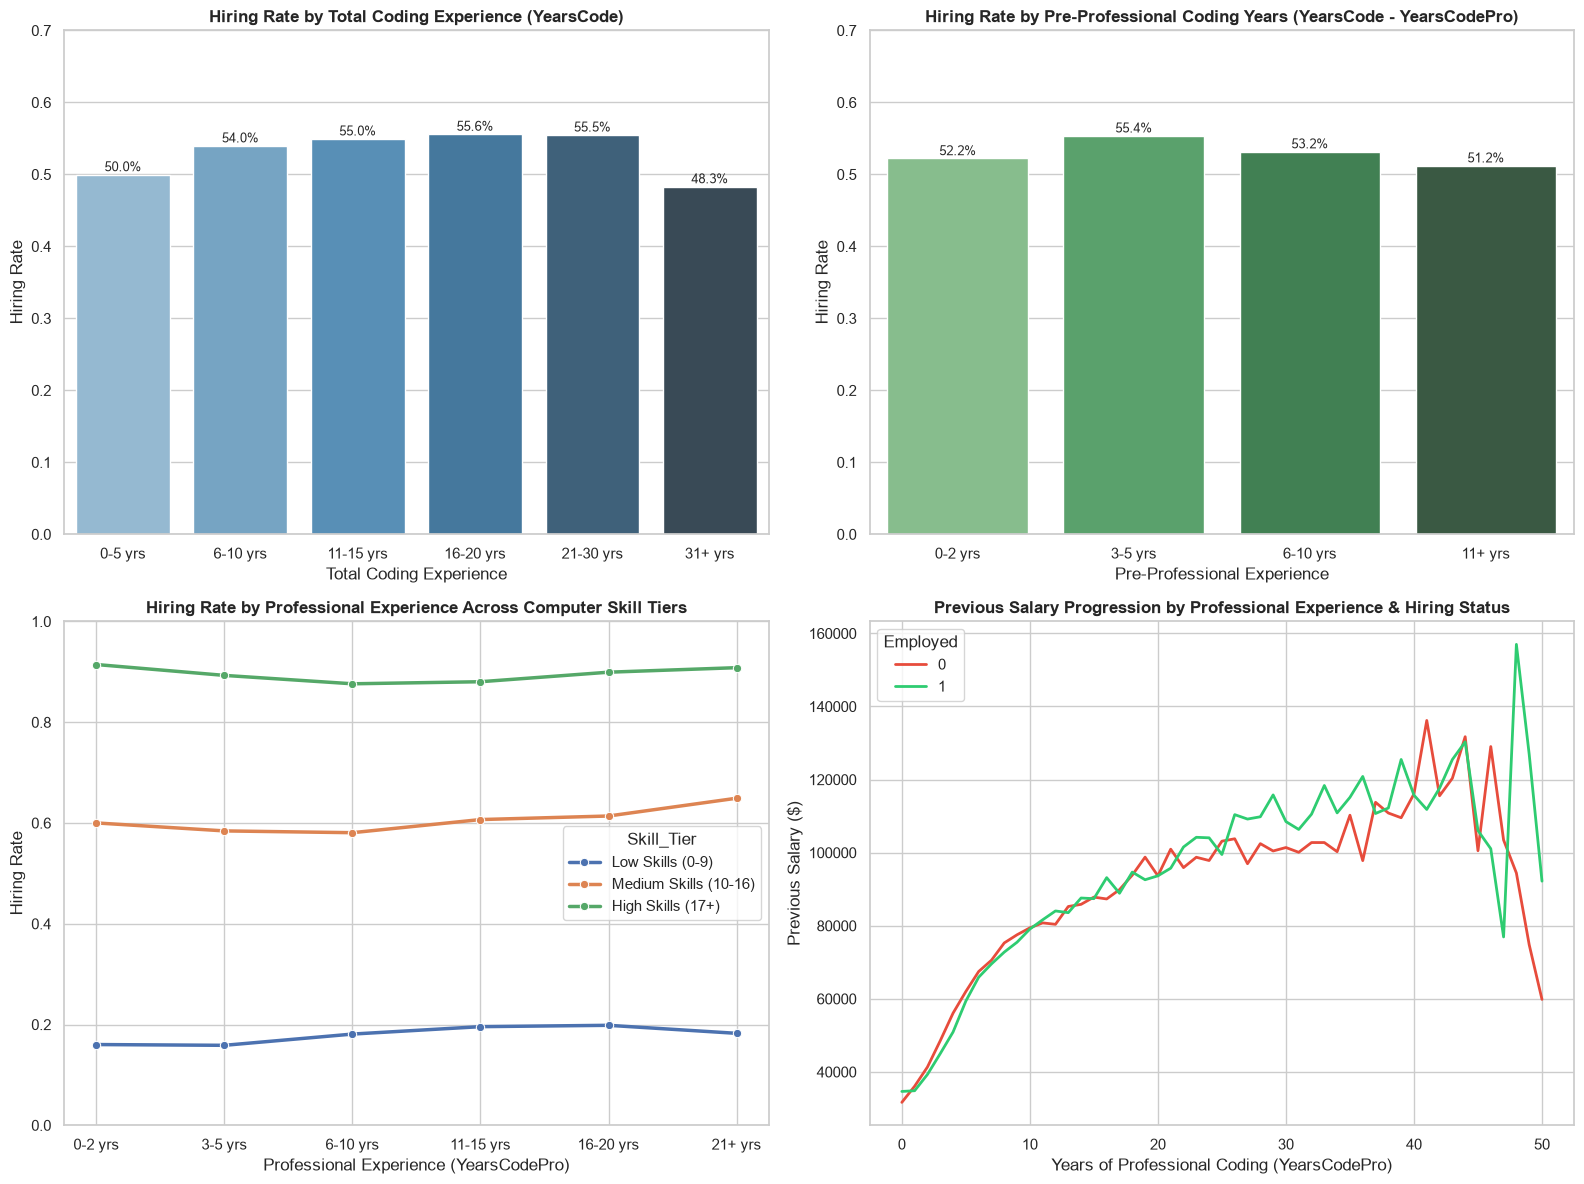

<Figure size 640x480 with 0 Axes>

In [31]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Total Coding Experience vs Hiring Rate
exp_df = df.groupby('YearsCode_Bin', observed=False)['Employed'].mean().reset_index()

sns.barplot(data=exp_df, x='YearsCode_Bin', y='Employed', ax=axes[0, 0], palette='Blues_d')
axes[0, 0].set_title('Hiring Rate by Total Coding Experience (YearsCode)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Hiring Rate')
axes[0, 0].set_xlabel('Total Coding Experience')
axes[0, 0].set_ylim(0, 0.7)
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f"{p.get_height():.1%}", (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9)

# Plot 2: Non-Professional Experience vs Hiring Rate
nonpro_df = df.groupby('NonPro_Bin', observed=False)['Employed'].mean().reset_index()
sns.barplot(data=nonpro_df, x='NonPro_Bin', y='Employed', ax=axes[0, 1], palette='Greens_d')
axes[0, 1].set_title('Hiring Rate by Pre-Professional Coding Years (YearsCode - YearsCodePro)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Hiring Rate')
axes[0, 1].set_xlabel('Pre-Professional Experience')
axes[0, 1].set_ylim(0, 0.7)
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f"{p.get_height():.1%}", (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9)

# Plot 3: Interaction of Professional Experience & Skill Tiers on Hiring
skill_exp = df.groupby(['YearsCodePro_Bin', 'Skill_Tier'], observed=False)['Employed'].mean().reset_index()
sns.lineplot(data=skill_exp, x='YearsCodePro_Bin', y='Employed', hue='Skill_Tier', marker='o', ax=axes[1, 0], linewidth=2.5)
axes[1, 0].set_title('Hiring Rate by Professional Experience Across Computer Skill Tiers', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Hiring Rate')
axes[1, 0].set_xlabel('Professional Experience (YearsCodePro)')
axes[1, 0].set_ylim(0, 1.0)

# Plot 4: Salary Progression by Experience and Hiring Status
sns.lineplot(data=df, x='YearsCodePro', y='PreviousSalary', hue='Employed', ax=axes[1, 1], palette={0: '#e74c3c', 1: '#2ecc71'}, errorbar=None, linewidth=2)
axes[1, 1].set_title('Previous Salary Progression by Professional Experience & Hiring Status', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Previous Salary ($)')
axes[1, 1].set_xlabel('Years of Professional Coding (YearsCodePro)')
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

Plot 1:

Employment increases gradually up to a moderate level of experience, then begins to decline among respondents with very high experience. Experience alone does not guarantee hiring.

Plot 2:

Having non-professional experience appears beneficial, but substantially greater non-professional experience is not associated with a higher hiring rate.

Plot 3:

The High Skills lines are clearly above the Low Skills lines across different experience levels, this suggests that skills have a stronger relationship with employment than years of experience alone.

In other words, someone with 20 years of experience but weaker skills may have a lower hiring rate than someone with 5 years of experience and stronger skills.

Plot 4:

As professional experience increases, previous salary generally tends to increase.

## Accessibility & Mental Health

In [32]:
print(df['Accessibility'].value_counts())
print(df['MentalHealth'].value_counts())

Accessibility
False    71355
True      2107
Name: count, dtype: int64
MentalHealth
False    56944
True     16518
Name: count, dtype: int64


clearly there are less indivisuals with mental health and accessibility problems across the data.

Do indivisuals with accessibility problems have lower employment rates?

In [33]:
a_employment = df.groupby('Accessibility')['Employment'].mean()* 100
print(a_employment.round(2).astype(str) + "%")

Accessibility
False     88.4%
True     85.33%
Name: Employment, dtype: str


88.4% unemployed

85.33% employed

from the data the rates between employed and unemployed with accessibility were close to each other with a slightly higher tendency for unemployement

Do employees with mental health conditions have lower employment rates(as a precentage) ?

In [34]:
mh_employment = df.groupby('MentalHealth')['Employment'].mean() * 100
print(mh_employment.round(2).astype(str) + "%")

MentalHealth
False    88.13%
True     88.93%
Name: Employment, dtype: str


88.1% unemployed and 88.9% employed is a very close factor so it does not really reduce employment rates

How do combined factors (mental health + accessibility) influence employement?

In [35]:
combined= df.groupby(['Accessibility','MentalHealth'])['Employment'].mean() * 100
print(combined.unstack())

MentalHealth       False      True 
Accessibility                      
False          88.194121  89.130575
True           84.842884  85.853659


Mental health conditions doesn't reduce employment much
but accessibility does

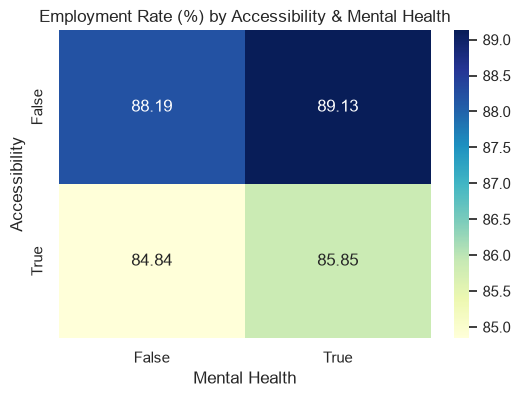

In [36]:
heatmap_data = combined.unstack()
plt.figure(figsize=(6,4))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlGnBu")

plt.title("Employment Rate (%) by Accessibility & Mental Health")
plt.ylabel("Accessibility")
plt.xlabel("Mental Health")
plt.show()

Did the people with Accessibility or mental health problems get hired in a higher rate after the surevy


In [37]:
mh_employment = df.groupby('MentalHealth')['Employed'].mean() * 100
print(mh_employment.round(2).astype(str) + "%")
a_employment = df.groupby('Accessibility')['Employed'].mean()* 100
print(a_employment.round(2).astype(str) + "%")
combined= df.groupby(['Accessibility','MentalHealth'])['Employed'].mean() * 100
print(combined.unstack())

MentalHealth
False    53.02%
True     55.71%
Name: Employed, dtype: str
Accessibility
False    53.53%
True     56.72%
Name: Employed, dtype: str
MentalHealth       False      True 
Accessibility                      
False          52.968028  55.560576
True           55.545287  57.951220


as we see from the results there is an increase in hiring rate after the survey for people with accessiability and mental health conditions

## Age, Gender, and Country

<BarContainer object of 3 artists>

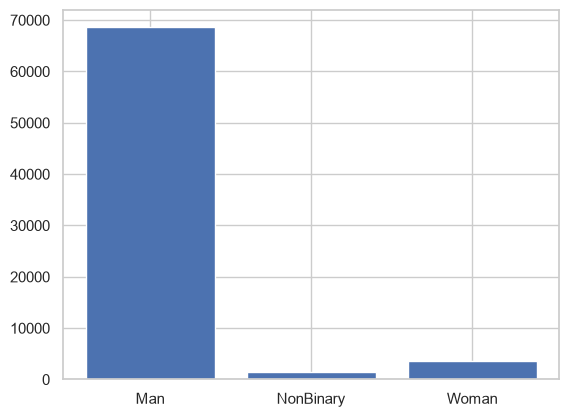

In [38]:
plt.bar(df.groupby('Gender')['id'].count().index, df.groupby('Gender')['id'].count())

In [39]:
(df['Gender'] == "Man").mean()

np.float64(0.9334485856633361)

~93.3% of indivisuals are men.

In [40]:
df['AgeAbove35'].mean()

np.float64(0.3490648226293866)

~35% of indivisuals are above 35.

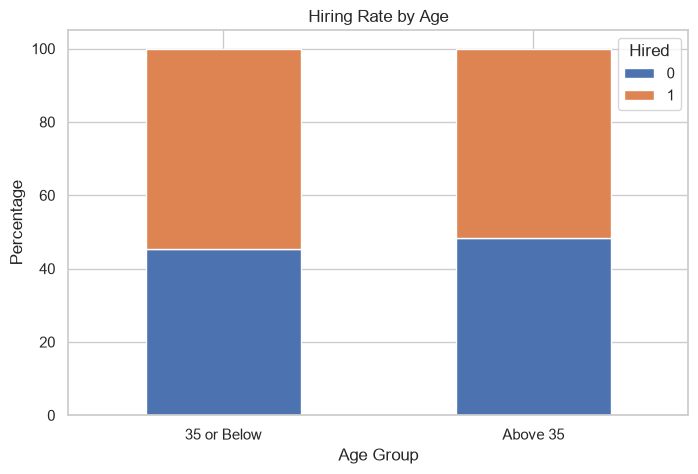

In [41]:
age_emp = pd.crosstab(
    df['AgeAbove35'],
    df['Employed'],
    normalize='index'
) * 100

age_emp.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Hiring Rate by Age')
plt.xlabel('Age Group')
plt.ylabel('Percentage')
plt.xticks(
    [0, 1],
    ['35 or Below', 'Above 35'],
    rotation=0
)
plt.legend(title='Hired')
plt.show()

In [42]:
pd.crosstab(
    df['Gender'],
    df['Employed'],
    normalize='index'
) * 100

Employed,0,1
Gender,,
Man,45.923323,54.076677
NonBinary,46.681255,53.318745
Woman,55.116543,44.883457


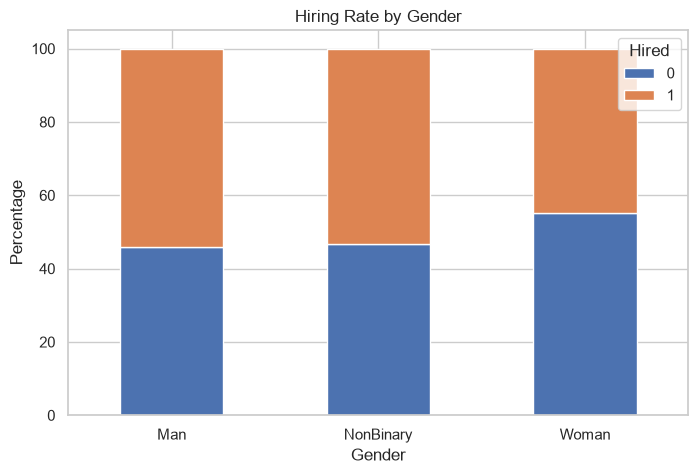

In [43]:
gender_emp = pd.crosstab(
    df['Gender'],
    df['Employed'],
    normalize='index'
) * 100

gender_emp.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Hiring Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Hired')
plt.show()

In [44]:
top_countries = df['Country'].value_counts().head(10).index

pd.crosstab(
    df[df['Country'].isin(top_countries)]['Country'],
    df[df['Country'].isin(top_countries)]['Employed'],
    normalize='index'
) * 100

Employed,0,1
Country,,
Brazil,45.160061,54.839939
Canada,46.995322,53.004678
France,48.528302,51.471698
Germany,47.784986,52.215014
India,49.347015,50.652985
Netherlands,46.337308,53.662692
Poland,50.936524,49.063476
Spain,48.247664,51.752336
United Kingdom of Great Britain and Northern Ireland,47.653584,52.346416


There is no bias between the top 10 most common countries.

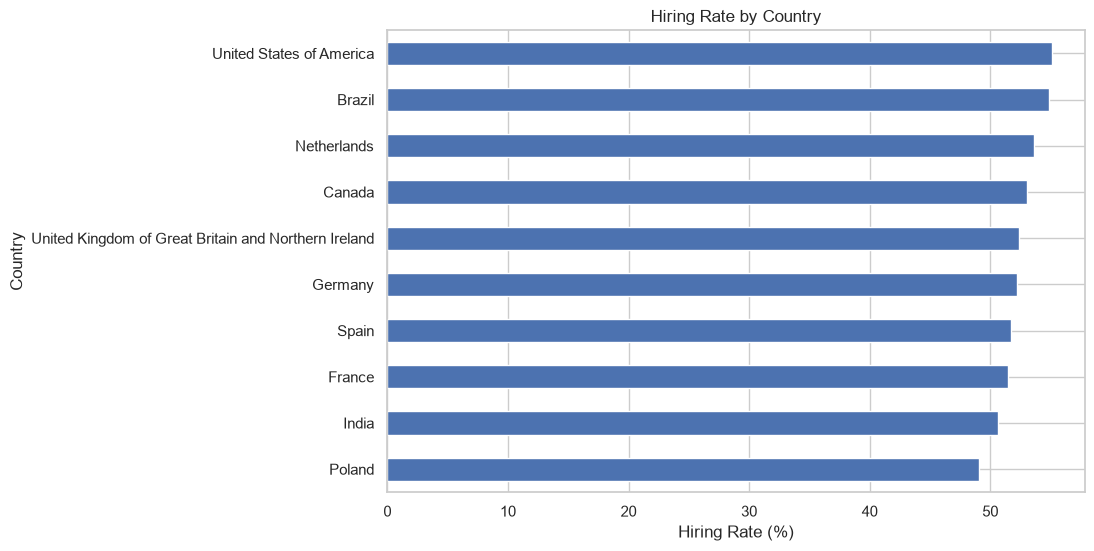

In [45]:
country_emp = pd.crosstab(
    df[df['Country'].isin(top_countries)]['Country'],
    df[df['Country'].isin(top_countries)]['Employed'],
    normalize='index'
) * 100

country_emp[1].sort_values().plot(
    kind='barh',
    figsize=(9,6)
)

plt.title('Hiring Rate by Country')
plt.xlabel('Hiring Rate (%)')
plt.ylabel('Country')
plt.show()

In [46]:
pd.crosstab(
    [df['AgeAbove35'], df['Gender']],
    df['Employed'],
    normalize='index'
) * 100

Employed                      0          1
AgeAbove35 Gender                         
0          Man        44.807523  55.192477
           NonBinary  43.973214  56.026786
           Woman      53.720930  46.279070
1          Man        47.965332  52.034668
           NonBinary  51.789474  48.210526
           Woman      58.955224  41.044776

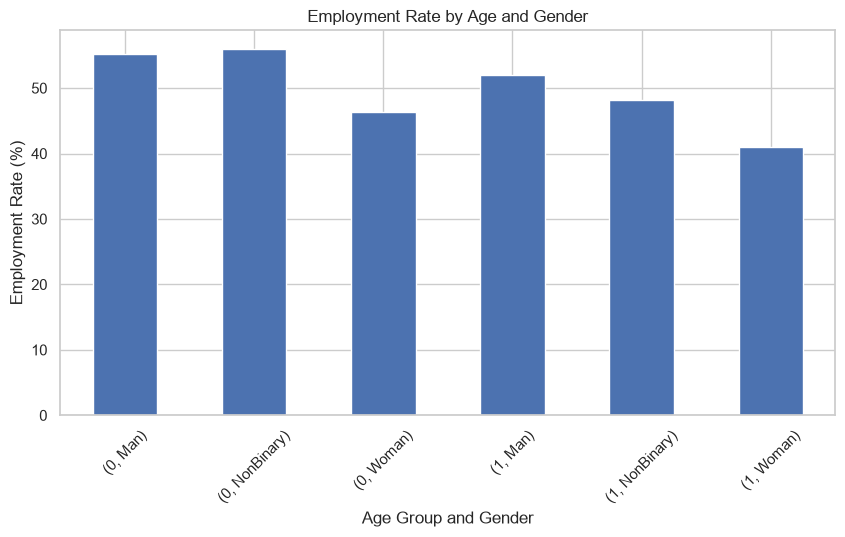

In [47]:
age_gender_emp = pd.crosstab(
    [df['AgeAbove35'], df['Gender']],
    df['Employed'],
    normalize='index'
) * 100

age_gender_emp[1].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Employment Rate by Age and Gender')
plt.xlabel('Age Group and Gender')
plt.ylabel('Employment Rate (%)')
plt.xticks(rotation=45)
plt.show()

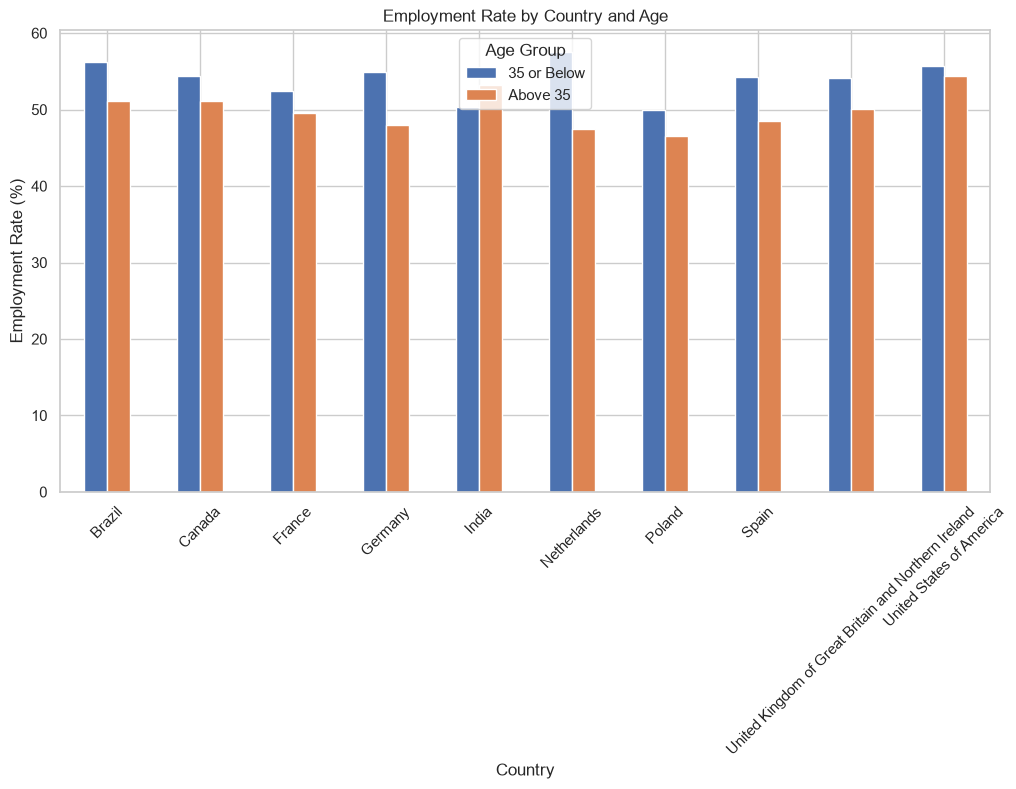

In [48]:
country_age_emp = pd.crosstab(
    [df[df['Country'].isin(top_countries)]['Country'],
     df[df['Country'].isin(top_countries)]['AgeAbove35']],
    df[df['Country'].isin(top_countries)]['Employed'],
    normalize='index'
) * 100

employment_rate = country_age_emp[1].unstack()

employment_rate.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Employment Rate by Country and Age')
plt.xlabel('Country')
plt.ylabel('Employment Rate (%)')
plt.xticks(rotation=45)
plt.legend(
    ['35 or Below', 'Above 35'],
    title='Age Group'
)
plt.show()

In [49]:
salary_country = (
    df[df['Country'].isin(top_countries)]
    .groupby('Country')['PreviousSalary']
    .median()
    .sort_values()
)

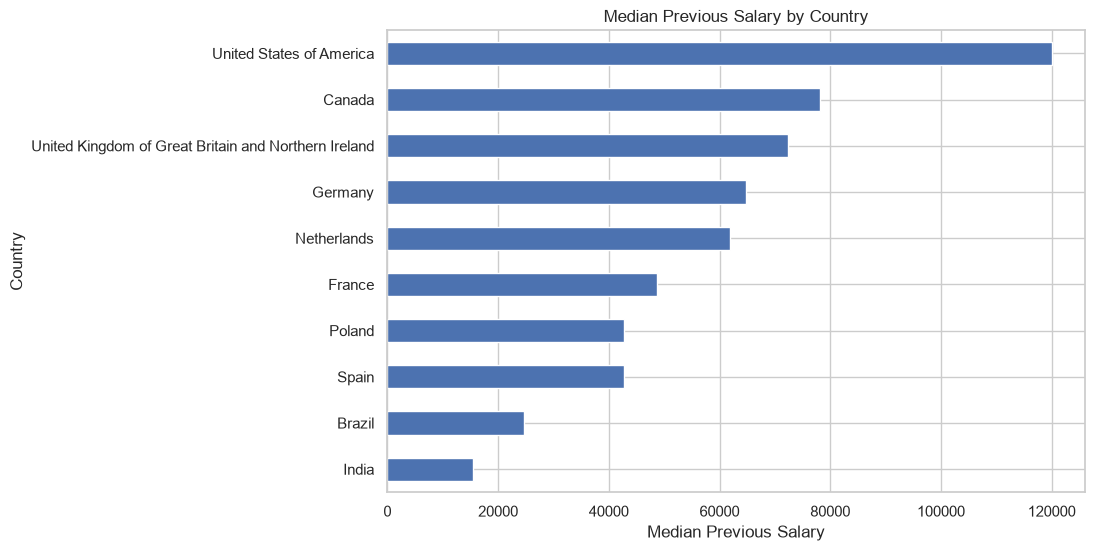

In [50]:
salary_country.plot(
    kind='barh',
    figsize=(9,6)
)

plt.title('Median Previous Salary by Country')
plt.xlabel('Median Previous Salary')
plt.ylabel('Country')
plt.show()

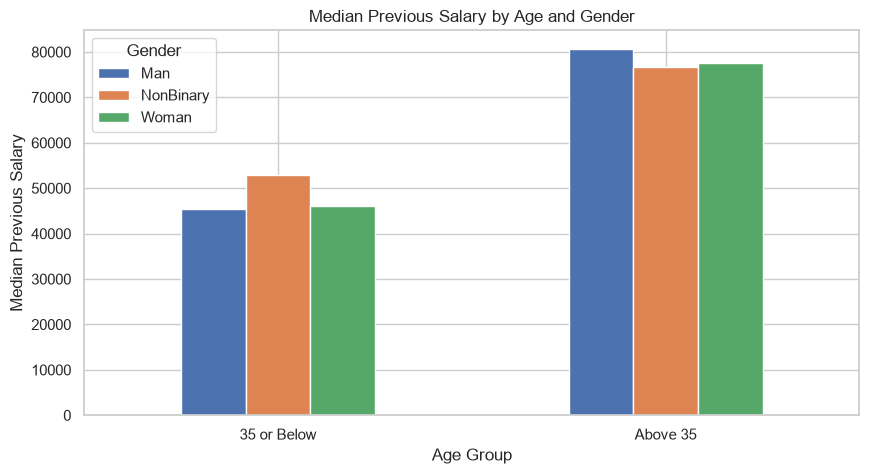

In [51]:
salary_age_gender = (
    df.groupby(['AgeAbove35', 'Gender'])['PreviousSalary']
      .median()
      .unstack()
)

salary_age_gender.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Median Previous Salary by Age and Gender')
plt.xlabel('Age Group')
plt.ylabel('Median Previous Salary')
plt.xticks(
    [0, 1],
    ['35 or Below', 'Above 35'],
    rotation=0
)
plt.show()

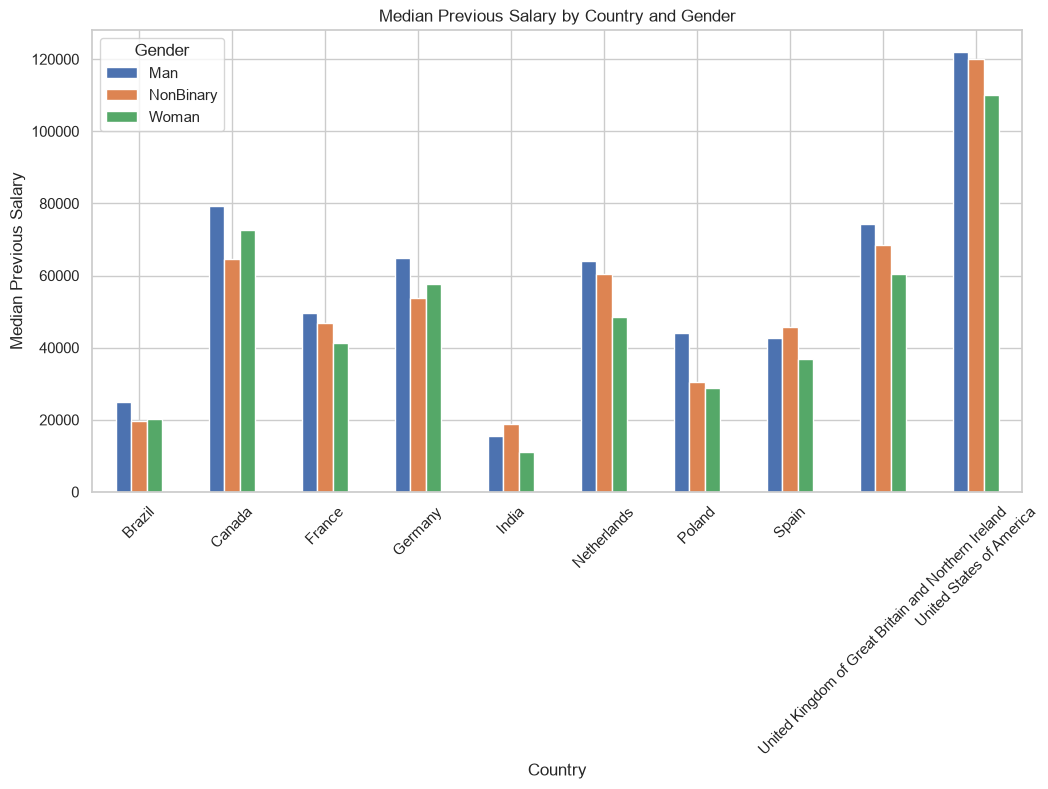

In [52]:
salary_country_gender = (
    df[df['Country'].isin(top_countries)]
    .groupby(['Country', 'Gender'])['PreviousSalary']
    .median()
    .unstack()
)

salary_country_gender.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Median Previous Salary by Country and Gender')
plt.xlabel('Country')
plt.ylabel('Median Previous Salary')
plt.xticks(rotation=45)
plt.show()

In [53]:
age_edlevel = pd.crosstab(
    df['AgeAbove35'],
    df['EdLevel'],
    normalize='index'
) * 100

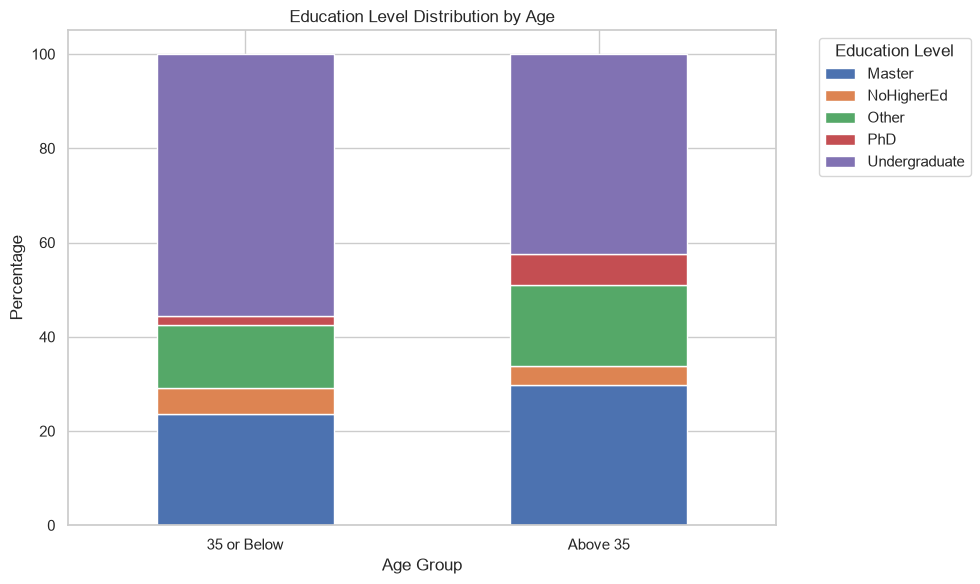

In [54]:
age_edlevel.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Education Level Distribution by Age')
plt.xlabel('Age Group')
plt.ylabel('Percentage')
plt.xticks(
    [0, 1],
    ['35 or Below', 'Above 35'],
    rotation=0
)

plt.legend(
    title='Education Level',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

## Education Level & Main Branch

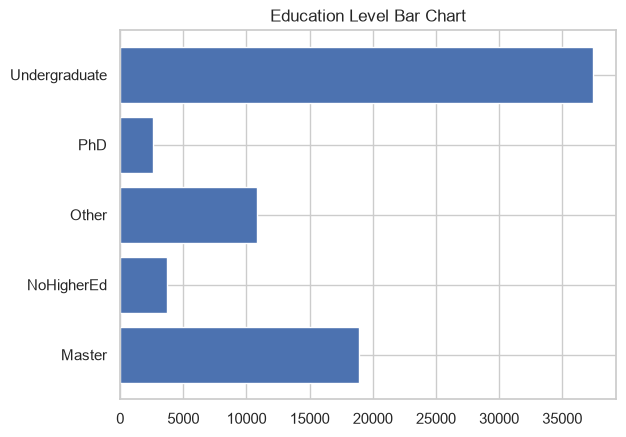

In [55]:
plt.barh(df.groupby('EdLevel')['id'].count().index, df.groupby('EdLevel')['id'].count())
plt.title('Education Level Bar Chart')
plt.show()

In [56]:
(df['MainBranch'] == "Dev").mean()

np.float64(0.9174266967956223)

91.7% of indivisuals are developers.

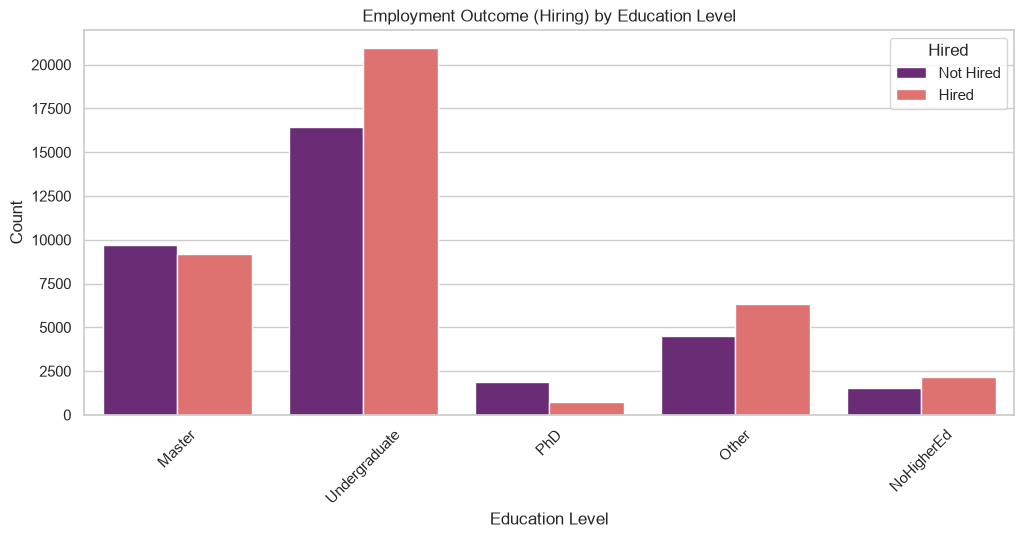

In [57]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='EdLevel', hue='Employed', palette='magma')

plt.title('Employment Outcome (Hiring) by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Hired', labels=['Not Hired', 'Hired'])
plt.show()

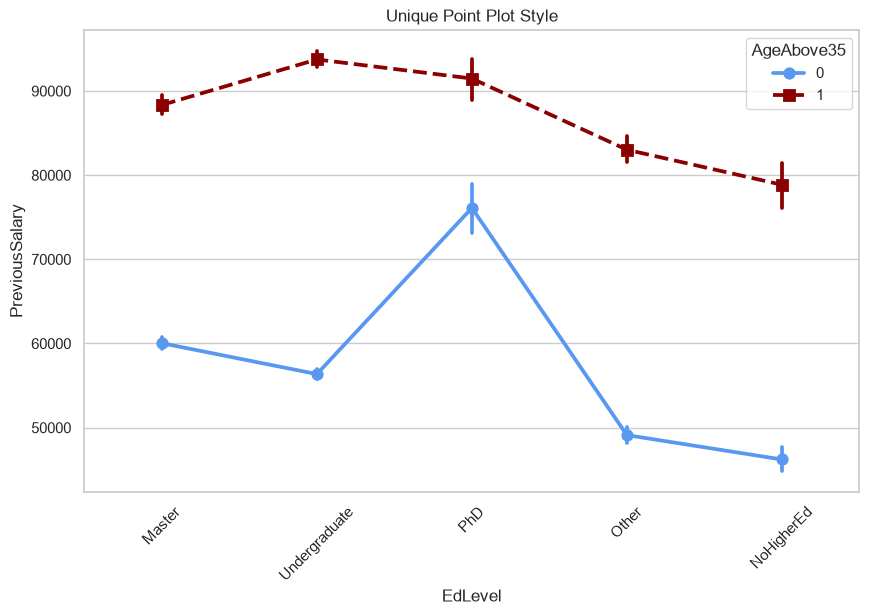

In [58]:
custom_palette = ["#5898f1", "#8B0000"]

plt.figure(figsize=(10, 6))
sns.pointplot(
    data=df,
    x="EdLevel",
    y="PreviousSalary", 
    hue="AgeAbove35",
    palette=custom_palette,
    markers=["o", "s"],
    linestyles=["-", "--"],
)

plt.title("Unique Point Plot Style")
plt.xticks(rotation=45)
plt.show()

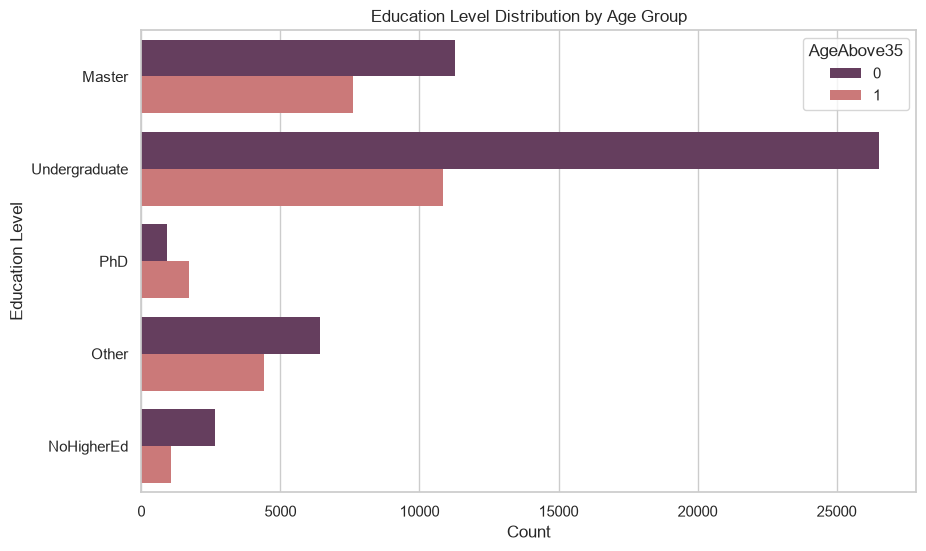

In [59]:
custom_palette = ["#6B3862", "#D96B6B"]

plt.figure(figsize=(10, 6))
sns.countplot(
    y="EdLevel",
    hue="AgeAbove35",
    data=df,
    palette=custom_palette,
    edgecolor="none",
)

plt.title("Education Level Distribution by Age Group")
plt.xlabel("Count")
plt.ylabel("Education Level")
plt.legend(title="AgeAbove35")
plt.show()

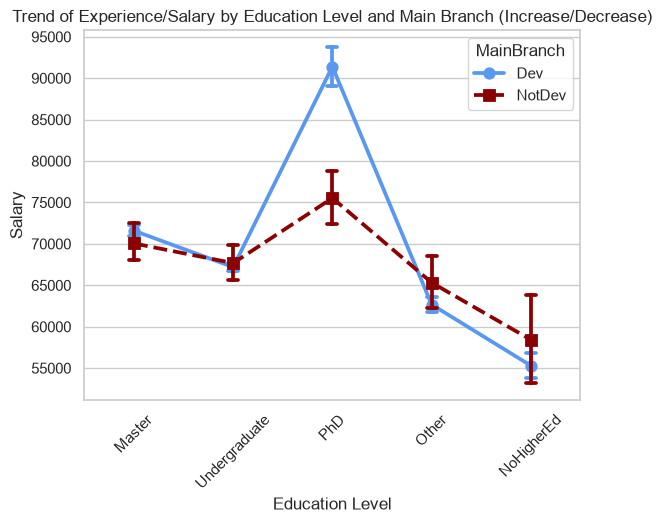

In [60]:
custom_palette = ["#5898f1", "#8B0000"]

sns.pointplot(
    x="EdLevel",
    y="PreviousSalary", 
    hue="MainBranch",
    data=df,
    palette=custom_palette,
    markers=["o", "s"],
    linestyles=["-", "--"],
    capsize=0.1,
)

plt.title(
    "Trend of Experience/Salary by Education Level and Main Branch (Increase/Decrease)"
)
plt.xticks(rotation=45)
plt.xlabel("Education Level")
plt.ylabel("Salary")
plt.show()